# Veri Madenciliği Projesi

Bu notebook, proje kapsamında istenen veri analizi, sınıflama ve kümeleme işlemlerini adım adım gerçekleştirmek için hazırlanmıştır.

## 1. Veri Yükleme ve Ön İnceleme

- Gerekli kütüphanelerin yüklenmesi
- Veri setinin okunması ve ilk gözlemler

In [4]:
import pandas as pd

# Veri setini yükle
df = pd.read_csv('data.csv')

# İlk bakış
df.head(), df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

(   Bankrupt?   ROA(C) before interest and depreciation before interest  \
 0          1                                           0.370594          
 1          1                                           0.464291          
 2          1                                           0.426071          
 3          1                                           0.399844          
 4          1                                           0.465022          
 
     ROA(A) before interest and % after tax  \
 0                                 0.424389   
 1                                 0.538214   
 2                                 0.499019   
 3                                 0.451265   
 4                                 0.538432   
 
     ROA(B) before interest and depreciation after tax  \
 0                                           0.405750    
 1                                           0.516730    
 2                                           0.472295    
 3                              

## 2. Veri Analizi

- Özelliklerin anlamı ve genel dağılımlar
- Sınıf sayısı, isimleri ve örnek dağılımları
- Eksik veri analizi ve giderme yöntemleri
- Aykırı değer tespiti ve analizi

## 2.1 Veri Seti Özeti

**Örnek Sayısı ve Özelliklerin Sayısı**  
- Toplam örnek sayısı: **6819**  
- Toplam sütun sayısı: **96**  
  - Hedef değişken: `Bankrupt?`  
  - Özellikler: 95 adet finansal gösterge  

**Hedef Değişken (Sınıf Etiketi)**  
- Sütun adı: `Bankrupt?`  
- Anlamı:  
  - **0** → İflas etmemiş  
  - **1** → İflas etmiş  

| Sınıf (Label) | Anlam         | Örnek Sayısı |
|--------------:|---------------|-------------:|
| 0             | Non-bankrupt  | 6599         |
| 1             | Bankrupt      | 220          |

**Özelliklerin (Feature) İçeriği ve Anlamları**  
Veri setindeki 95 özellik, şirketlerin finansal performansını ölçen oran ve marjlardan oluşuyor. Ana gruplar:  
1. **Kârlılık Oranları**  
   - ROA (faiz ve vergi öncesi/sonrası)  
   - Operating Profit Rate, Net Interest Rate  
2. **Marjlar**  
   - Operating Gross Margin  
   - Realized Sales Gross Margin  
   - Sales/Assets, Sales/Equity  
3. **Likidite ve Aktif Kullanım Oranları**  
   - Current Ratio, Quick Ratio  
   - Inventory Turnover, Receivables Turnover  
4. **Borçluluk ve Finansman Oranları**  
   - Debt/Equity, Interest Coverage  
5. **Diğer Finansal Göstergeler**  
   - Cash Flow Ratios, Non-Industry Income/Revenue  


In [2]:
# Mevcut sütun isimlerini listeleme
print(df.columns.tolist())


['Bankrupt?', ' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Regular Net Profit Growth Rate', ' Continuous Net Profit Growth 

In [5]:
# Sınıf bilgileri
print('Sınıf sayısı:', df['Bankrupt?'].nunique())
print('Sınıf isimleri ve örnek sayıları:')
print(df['Bankrupt?'].value_counts())

# Eksik veri kontrolü
print('Eksik değerler:')
print(df.isnull().sum())

# Aykırı değer analizi örneği (örneğin Z-score yöntemi)
from scipy import stats
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(df[numeric_cols].dropna()))
outliers = (z_scores > 3).sum(axis=0)
print('Aykırı değer sayıları (Z>3):')
print(dict(zip(numeric_cols, outliers)))

Sınıf sayısı: 2
Sınıf isimleri ve örnek sayıları:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64
Eksik değerler:
Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64
Aykırı değer sayıları (Z>3):
{'Bankrupt?': 220, ' ROA(C) before interest and depreciation before interest': 88, ' ROA(A) before interest and % after tax': 110, ' ROA(B) be

## 2.2 Eksik Veri Analizi

Bu bölümde:
- Sütunlardaki eksik değer sayıları ve oranları incelenecek.  
- Eksik veri durumuna göre basit doldurma (imputation) veya silme yöntemleri örneklenecek.
## 2.2.1 Medyan Değeri ile Doldurma 
- Aykırı değerlerden etkilenmeyen merkezi bir eğilim ölçüsü sağladığı için tercih edilir,

- Özellikle finansal veriler gibi çarpık dağılıma sahip veri setlerinde ortalama yerine daha güvenlidir,

- Kategorik veri içermeyen bu veri setinde oldukça uygundur.

,missing_count,missing_pct
Bankrupt?,0,0.0
ROA(C) before interest and depreciation before interest,0,0.0
Total expense/Assets,0,0.0
Total income/Total expense,0,0.0
Retained Earnings to Total Assets,0,0.0
Long-term Liability to Current Assets,0,0.0
Current Liabilities/Equity,0,0.0
Working Capital/Equity,0,0.0
Current Liabilities/Liability,0,0.0
Inventory/Current Liability,0,0.0


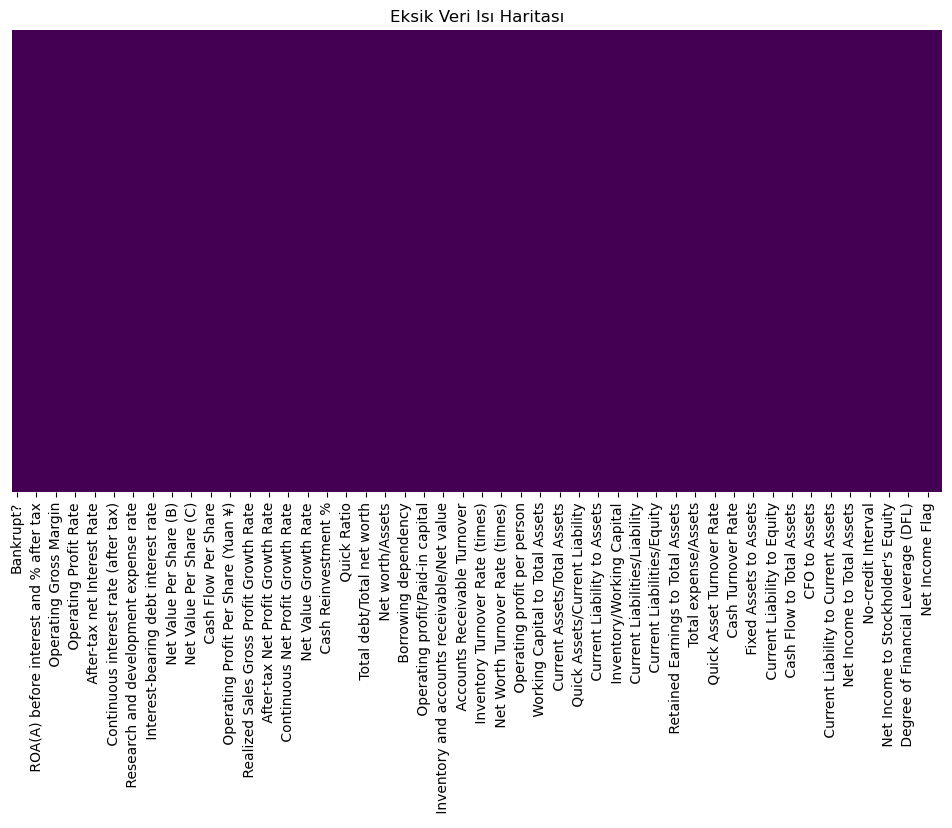

Eksik değerler medyan ile dolduruldu.


In [8]:
# --- Eksik Veri Özeti ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Eksik değer sayısı ve yüzdesi
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100
missing_df    = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

# İlk 10 sütunu göster
display(missing_df.head(10))

# 2) Eksik veri ısı haritası
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Eksik Veri Isı Haritası')
plt.show()

# 3) Basit doldurma örneği: numerik sütunlar için medyan ile
num_cols = df.select_dtypes(include='number').columns.drop('Bankrupt?')
df_imputed = df.copy()
for col in num_cols:
    median = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median)
print("Eksik değerler medyan ile dolduruldu.")


### 2.2.2 KNN ile Tahmin Temelli Doldurma

Bu bölümde, sayısal sütunlardaki eksik değerleri KNNImputer ile komşu örneklerin ortalaması üzerinden doldurulması gösterilmiştir.


In [10]:
from sklearn.impute import KNNImputer

# Sadece sayısal sütunlar
num_cols = df.select_dtypes(include='number').columns.drop('Bankrupt?')

# KNNImputer nesnesi (örneğin 5 komşu)
imputer = KNNImputer(n_neighbors=5, weights='uniform')

# Kopya veri çerçevesi oluştur
df_knn = df.copy()

# Imputation uygula
df_knn[num_cols] = imputer.fit_transform(df_knn[num_cols])

# Eksik değer kalmadığını doğrula
print("KNN ile doldurduktan sonra eksik değer sayısı:")
print(df_knn[num_cols].isnull().sum().sum())


KNN ile doldurduktan sonra eksik değer sayısı:
0


## 2.3 Aykırı Değer Tespiti

Bu bölümde:
- Numerik özellikler için Z-score ve IQR yöntemleriyle aykırı değer sayıları hesaplanacak.  
- Örnek olarak bazı sütunlarda boxplot ile görselleştirme yapılacak.


Fixed Assets Turnover Frequency        251
Cash/Total Assets                      167
Interest-bearing debt interest rate    146
Total Asset Turnover                   135
Cash Flow to Total Assets              134
Cash Flow to Liability                 122
Operating Funds to Liability           116
Net Value Per Share (C)                115
Net Value Per Share (A)                115
Net Value Per Share (B)                115
dtype: int64

Degree of Financial Leverage (DFL)                    1503
Interest Coverage Ratio (Interest expense to EBIT)    1421
Fixed Assets Turnover Frequency                       1418
Current Asset Turnover Rate                           1399
Total Asset Growth Rate                               1381
Interest Expense Ratio                                1362
Cash Flow to Liability                                1212
No-credit Interval                                    1139
Non-industry income and expenditure/revenue           1094
Cash Flow to Sales                                    1052
dtype: int64

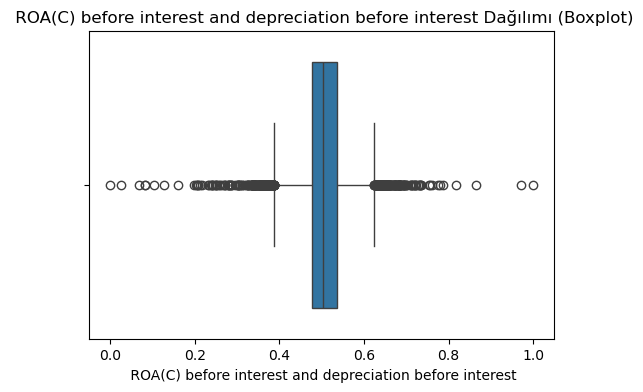

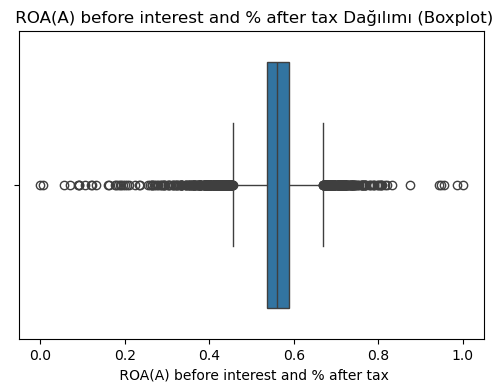

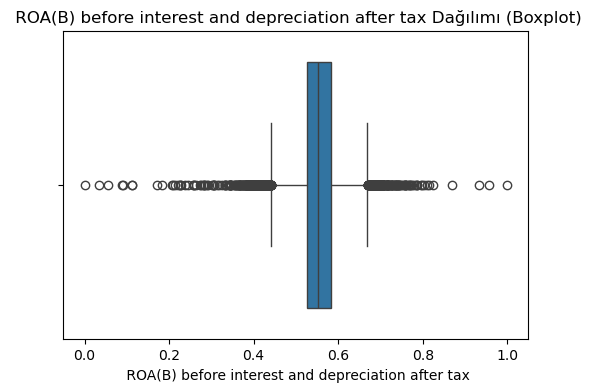

In [ ]:
# --- Z-score ile Aykırı Değer Sayısı ---
from scipy import stats
import numpy as np

# Z-score
z_scores = np.abs(stats.zscore(df_imputed[num_cols]))
outlier_mask_z = (z_scores > 3)
outlier_counts_z = pd.Series(outlier_mask_z.sum(axis=0), index=num_cols).sort_values(ascending=False)
display(outlier_counts_z.head(10))

# --- IQR ile Aykırı Değer Sayısı ---
Q1 = df_imputed[num_cols].quantile(0.25)
Q3 = df_imputed[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask_iqr = ((df_imputed[num_cols] < (Q1 - 1.5 * IQR)) | (df_imputed[num_cols] > (Q3 + 1.5 * IQR)))
outlier_counts_iqr = outlier_mask_iqr.sum().sort_values(ascending=False)
display(outlier_counts_iqr.head(10))

# --- Boxplot Örneği ---
for col in num_cols[:3]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_imputed[col])
    plt.title(f'{col} Dağılımı')
    plt.xlabel(col)
    plt.show()


## 3. Özelliklerin Sınıflamadaki Ayırt Ediciliği

Bu bölümde, sınıflandırma modeline en çok katkı sağlayan değişkenleri belirlemek amacıyla **Random Forest** algoritması kullanılmıştır.  
Random Forest, gömülü bir özellik seçim yöntemi olup her özelliğin sınıflandırma başarısına katkısını ölçerek önem dereceleri üretir.

Aşağıdaki analizde:
- `Bankrupt?` sınıf etiketine göre model eğitilmiş,
- Her bir değişkenin model tarafından ne derece ayırt edici olduğu hesaplanmıştır.

**Not:** Eksik veriler KNN yöntemiyle doldurulmuş olan `df_knn` veri çerçevesi kullanılmıştır.

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Örnek model ile özellik önemleri
model = RandomForestClassifier(random_state=42)
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Özellik önem sıralaması:')
print(importances)

Özellik önem sıralaması:
Net Income to Stockholder's Equity          0.030977
Net Value Growth Rate                       0.029460
Borrowing dependency                        0.024315
Persistent EPS in the Last Four Seasons     0.024205
Per Share Net profit before tax (Yuan ¥)    0.020203
                                              ...   
Fixed Assets to Assets                      0.005880
Cash Reinvestment %                         0.005651
Tax rate (A)                                0.002682
Liability-Assets Flag                       0.000242
Net Income Flag                             0.000000
Length: 95, dtype: float64


## 4. Sınıflama Yöntemleri: Karşılaştırmalı İnceleme

Bu bölümde, üç farklı sınıflama algoritması uygulanmış ve aşağıdaki kriterlere göre karşılaştırılmıştır:

- **Doğruluk (Accuracy)**: Test verisindeki genel başarı oranı  
- **Karışıklık Matrisi (Confusion Matrix)**: Her sınıf için doğru ve yanlış sınıflandırmaları detaylı gösterir

Seçtiğim algoritmalar:
1. **Logistic Regression**
2. **Support Vector Machine (SVM)**
3. **Random Forest Classifier**

Her model, `df_knn` veri çerçevesi (KNN ile eksik verisi giderilmiş) kullanılarak eğitilmiş ve test edilmiştir.


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression doğruluk: 0.9585
SVM doğruluk: 0.9677
Random Forest doğruluk: 0.9717


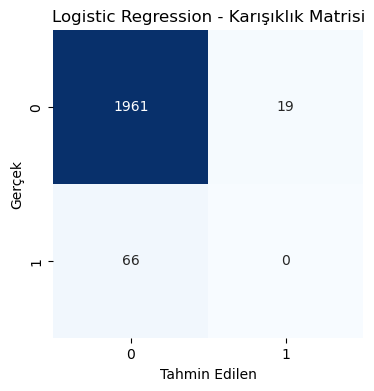

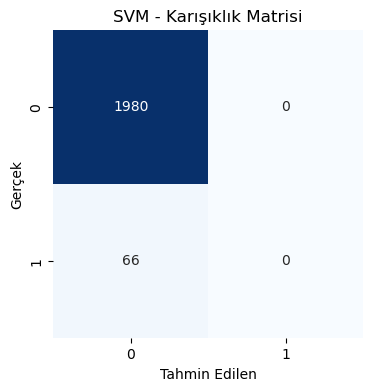

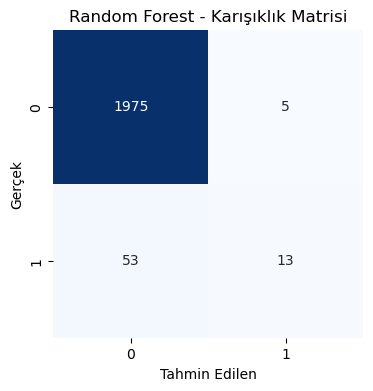

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi ayır
X = df_knn.drop('Bankrupt?', axis=1)
y = df_knn['Bankrupt?']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Modelleri tanımla
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Sonuçları tut
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {'accuracy': acc, 'confusion_matrix': cm, 'classification_report': classification_report(y_test, y_pred, output_dict=True)}

# Doğruluk skorlarını yazdır
for name, res in results.items():
    print(f"{name} doğruluk: {res['accuracy']:.4f}")

# Karışıklık matrislerini görselleştir
for name, res in results.items():
    plt.figure(figsize=(4,4))
    sns.heatmap(res['confusion_matrix'], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Karışıklık Matrisi')
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek')
    plt.show()


### 4.1 Sınıflandırma Sonuçlarının Raporlaştırılması

Her modelin sınıflandırma başarımı detaylı olarak Precision, Recall ve F1-Score metrikleri üzerinden değerlendirilmiştir.


In [13]:
import pandas as pd
from pandas.io.formats.style import Styler

# Raporları DataFrame olarak yazdır (sadece class 0 ve 1 için)
for name, res in results.items():
    print(f"\n{name} Classification Report:")
    report_df = pd.DataFrame(res['classification_report']).transpose().round(3).iloc[:2]
    display(report_df.style.set_caption(name).background_gradient(cmap='YlGnBu'))



Logistic Regression Classification Report:


,precision,recall,f1-score,support
0,0.967000,0.990000,0.979000,1980.000000
1,0.000000,0.000000,0.000000,66.000000



SVM Classification Report:


,precision,recall,f1-score,support
0,0.968000,1.000000,0.984000,1980.000000
1,0.000000,0.000000,0.000000,66.000000



Random Forest Classification Report:


,precision,recall,f1-score,support
0,0.974000,0.997000,0.986000,1980.000000
1,0.722000,0.197000,0.310000,66.000000


### 4.2 ROC Eğrileri ile Model Karşılaştırması

ROC eğrileri, modellerin sınıflandırmadaki ayrım gücünü görsel olarak karşılaştırmamıza olanak tanır.  
AUC (Area Under Curve) değeri ne kadar 1'e yakınsa, model o kadar başarılıdır.


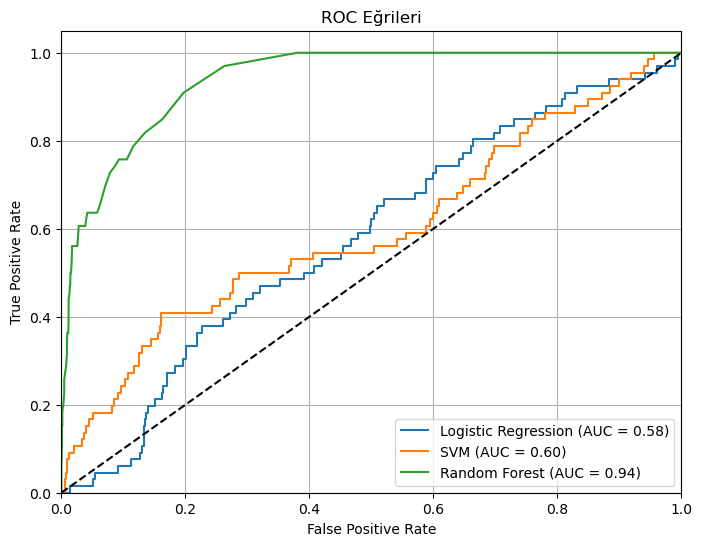

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC için modellerin tahmin olasılıkları gerekli
plt.figure(figsize=(8,6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        # SVM için decision_function kullanılır
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# ROC grafiği süslemeleri
plt.plot([0, 1], [0, 1], 'k--')  # rasgele sınıflandırma çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrileri')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## 5. Kümeleme

- Seçilecek 3 kümeleme yöntemi (ör. KMeans, DBSCAN, Agglomerative)
- Kümeleme sonuçlarının değerlendirilmesi ve gerçek sınıf etiketleri ile karşılaştırma

In [7]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import homogeneity_score, completeness_score

# 1) KMeans
kmeans = KMeans(n_clusters=df['Bankrupt?'].nunique(), random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# 2) DBSCAN
dbscan = DBSCAN()
labels_dbscan = dbscan.fit_predict(X)

# 3) Agglomerative
agg = AgglomerativeClustering(n_clusters=df['Bankrupt?'].nunique())
labels_agg = agg.fit_predict(X)

# Değerlendirme (örneğin homogeneity)
methods = ['KMeans', 'DBSCAN', 'Agglomerative']
scores = []
for name, labels in zip(methods, [labels_kmeans, labels_dbscan, labels_agg]):
    scores.append({
        'Method': name,
        'Homogeneity': homogeneity_score(y, labels),
        'Completeness': completeness_score(y, labels)
    })
print(scores)

[{'Method': 'KMeans', 'Homogeneity': 0.003304409824417919, 'Completeness': 0.0007678143900947674}, {'Method': 'DBSCAN', 'Homogeneity': 0.002067823261870695, 'Completeness': 0.005252772767900961}, {'Method': 'Agglomerative', 'Homogeneity': 0.00026907243453079706, 'Completeness': 6.352771726440494e-05}]


## 5. Kümeleme Yöntemleri: Karşılaştırmalı İnceleme

Bu bölümde üç kümeleme algoritması uygulanmış ve sonuçlar, veri setindeki gerçek sınıf etiketleriyle karşılaştırılarak değerlendirilmektedir.

**Kullanılan Kümeleme Yöntemleri:**
1. **K-Means**  
2. **DBSCAN**  
3. **Agglomerative Clustering**

Her algoritmanın başarımı şu metriklerle ölçülmüştür:
- **Homogeneity**: Her küme sadece tek bir sınıfa ait örnekleri içeriyor mu?  
- **Completeness**: Aynı sınıfa ait tüm örnekler aynı kümede mi?  
- **V-Measure**: Homogeneity ve completeness'in harmonik ortalaması  
- **Adjusted Rand Index (ARI)**: Gerçek etiketlerle küme etiketlerinin benzerliği


In [16]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score

# X: sadece özellikler, y: sınıf etiketleri
X = df_knn.drop('Bankrupt?', axis=1)
y = df_knn['Bankrupt?']

# Kümeleme algoritmalarını tanımla
clusterers = {
    'KMeans': KMeans(n_clusters=2, random_state=42),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5),  # eps parametresi ayarlanabilir
    'Agglomerative': AgglomerativeClustering(n_clusters=2)
}

# Sonuçları tutacağımız tablo
clustering_results = []

for name, model in clusterers.items():
    preds = model.fit_predict(X)

    # DBSCAN için: -1 = "gürültü", onu hariç tutabiliriz veya tümünü hesaba katabiliriz
    n_clusters = len(set(preds)) - (1 if -1 in preds else 0)

    metrics = {
        'Yöntem': name,
        'Küme Sayısı': n_clusters,
        'Homogeneity': homogeneity_score(y, preds),
        'Completeness': completeness_score(y, preds),
        'V-Measure': v_measure_score(y, preds),
        'Adjusted Rand Index': adjusted_rand_score(y, preds)
    }
    clustering_results.append(metrics)

# Sonuçları tablo olarak göster
import pandas as pd
clustering_df = pd.DataFrame(clustering_results).round(3)
clustering_df.sort_values('V-Measure', ascending=False, inplace=True)
clustering_df


,Yöntem,Küme Sayısı,Homogeneity,Completeness,V-Measure,Adjusted Rand Index
1,DBSCAN,4,0.003,0.005,0.003,-0.016
0,KMeans,2,0.003,0.001,0.001,0.009
2,Agglomerative,2,0.000,0.000,0.000,0.003


### 5.1 Kümeleme Sonuçlarının Görselleştirilmesi (PCA)

Her algoritmanın çıkardığı kümeler, PCA ile iki boyuta indirgenmiş veri üzerinde görselleştirilmiştir.  
Bu grafikler kümelerin birbirinden ayrışma derecesini gözle görmeyi sağlar.


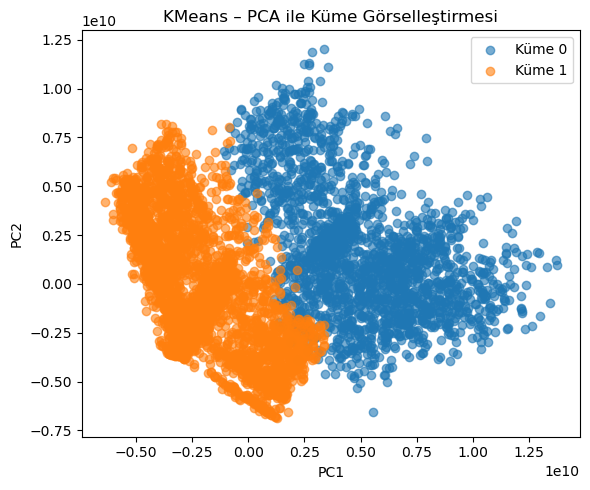

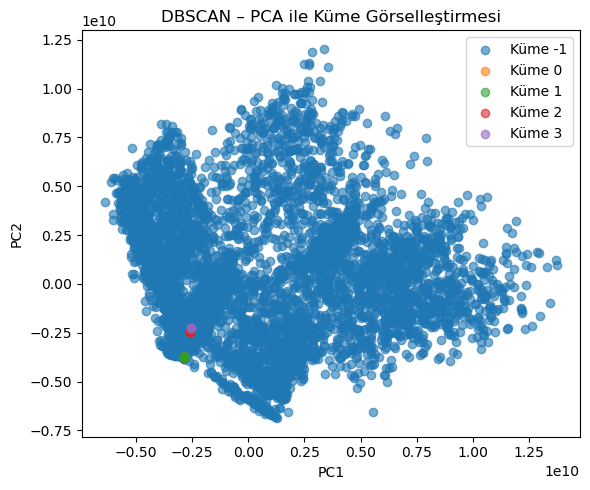

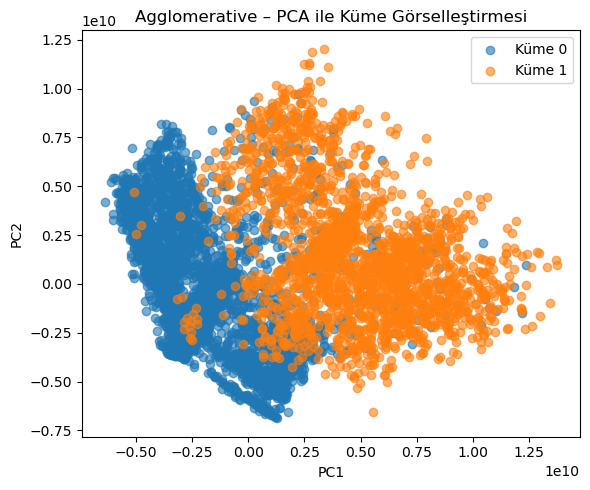

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA ile 2 boyuta indir
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Her kümeleme için scatter plot
for name, model in clusterers.items():
    preds = model.fit_predict(X)

    plt.figure(figsize=(6,5))
    for cluster_id in np.unique(preds):
        mask = preds == cluster_id
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Küme {cluster_id}", alpha=0.6)
    plt.title(f'{name} – PCA ile Küme Görselleştirmesi')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()


### 5.2 Kümeleme Kalitesi: Silhouette Skoru

**Silhouette Score**, her bir örneğin kendi kümesiyle olan uyumu ile en yakın diğer kümeye olan uzaklığı karşılaştırır.  
Skor 1'e yaklaştıkça kümeler iyi ayrışmıştır; 0'a yaklaştıkça örnekler kümeler arası kararsızdır.


In [18]:
from sklearn.metrics import silhouette_score

# Sonuçları tut
silhouette_scores = {}

for name, model in clusterers.items():
    preds = model.fit_predict(X)
    # -1 olanları (DBSCAN'in gürültüsü) hariç tut
    if len(set(preds)) > 1 and len(set(preds)) < len(X):
        valid_mask = preds != -1
        score = silhouette_score(X[valid_mask], np.array(preds)[valid_mask])
    else:
        score = np.nan  # anlamlı skor hesaplanamaz
    silhouette_scores[name] = score

# Skorları yazdır
print("Silhouette Skorları:")
for name, score in silhouette_scores.items():
    print(f"{name}: {score:.3f}" if not np.isnan(score) else f"{name}: hesaplanamadı")


Silhouette Skorları:
KMeans: 0.229
DBSCAN: 1.000
Agglomerative: 0.200


### 5.3 DBSCAN Parametre Ayarı (eps ve min_samples)

DBSCAN’in başarısı büyük ölçüde `eps` (komşu mesafesi) ve `min_samples` (çekirdek nokta eşiği) parametrelerine bağlıdır.  
Aşağıdaki analizle bu iki parametrenin kombinasyonları denenerek **homogeneity**, **v-measure** ve **silhouette score** üzerinden en uygun kombinasyon belirlenmeye çalışılmıştır.


In [23]:
from sklearn.metrics import silhouette_score, v_measure_score, homogeneity_score
import numpy as np

eps_values = np.linspace(0.5, 3.0, 6)
min_samples_values = [3, 5, 10]
results = []

for eps in eps_values:
    for min_s in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_s)
        preds = model.fit_predict(X)
        
        n_clusters = len(set(preds)) - (1 if -1 in preds else 0)
        
        if n_clusters >= 2:
            valid = preds != -1
            # Sadece geçerli örnekler üzerinden skorlar
            silhouette = silhouette_score(X[valid], np.array(preds)[valid])
            homo = homogeneity_score(y[valid], np.array(preds)[valid])
            vscore = v_measure_score(y[valid], np.array(preds)[valid])
            results.append({
                'eps': round(eps,2),
                'min_samples': min_s,
                'clusters': n_clusters,
                'silhouette': round(silhouette, 3),
                'homogeneity': round(homo, 3),
                'v_measure': round(vscore, 3)
            })
        else:
            print(f"Atlanan: eps={eps:.2f}, min_samples={min_s} → {n_clusters} küme")

# Sonuçları göster
import pandas as pd
df_dbscan_grid = pd.DataFrame(results).sort_values(by='v_measure', ascending=False)
df_dbscan_grid.head()


Atlanan: eps=0.50, min_samples=10 → 1 küme
Atlanan: eps=1.00, min_samples=10 → 1 küme
Atlanan: eps=1.50, min_samples=10 → 1 küme
Atlanan: eps=2.00, min_samples=10 → 1 küme
Atlanan: eps=2.50, min_samples=10 → 1 küme
Atlanan: eps=3.00, min_samples=10 → 1 küme


,eps,min_samples,clusters,silhouette,homogeneity,v_measure
0,0.5,3,12,0.706,1.0,0.0
1,0.5,5,3,1.000,1.0,0.0
2,1.0,3,11,1.000,1.0,0.0
3,1.0,5,4,1.000,1.0,0.0
4,1.5,3,11,1.000,1.0,0.0


### 5.4 KMeans ile Optimal Küme Sayısı Belirleme (Elbow Yöntemi)

Küme sayısını belirlemede yaygın bir yöntem olan **Elbow Method**, her küme sayısı için `inertia` (içsel varyans) değerini hesaplar.  
Grafikte `inertia`'nın ani yavaşladığı (dirsek yaptığı) nokta en uygun küme sayısını işaret eder.


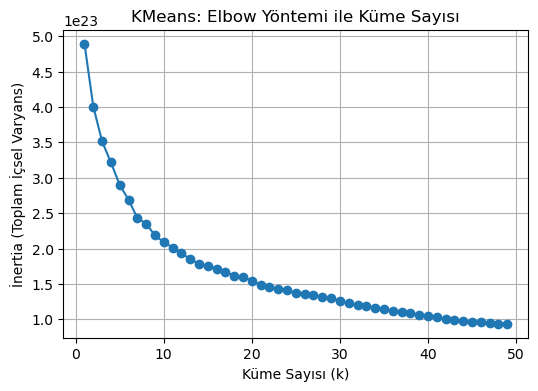

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_vals = []
k_values = range(1, 50)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia_vals.append(kmeans.inertia_)

# Dirsek (elbow) grafiği
plt.figure(figsize=(6,4))
plt.plot(k_values, inertia_vals, marker='o')
plt.title('KMeans: Elbow Yöntemi ile Küme Sayısı')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('İnertia (Toplam İçsel Varyans)')
plt.grid(True)
plt.show()


## 6. Sonuç ve Değerlendirme

- Yapılan işlemlerin özetlenmesi
- Elde edilen bulgular ve öneriler

Sayısal sütunlar: [' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Operating Gross Margin', ' Realized Sales Gross Margin', ' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Non-industry income and expenditure/revenue', ' Continuous interest rate (after tax)', ' Operating Expense Rate', ' Research and development expense rate', ' Cash flow rate', ' Interest-bearing debt interest rate', ' Tax rate (A)', ' Net Value Per Share (B)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Persistent EPS in the Last Four Seasons', ' Cash Flow Per Share', ' Revenue Per Share (Yuan ¥)', ' Operating Profit Per Share (Yuan ¥)', ' Per Share Net profit before tax (Yuan ¥)', ' Realized Sales Gross Profit Growth Rate', ' Operating Profit Growth Rate', ' After-tax Net Profit Growth Rate', ' Regular Net Profit Growth Rate', ' Continuous Net Profit Gr

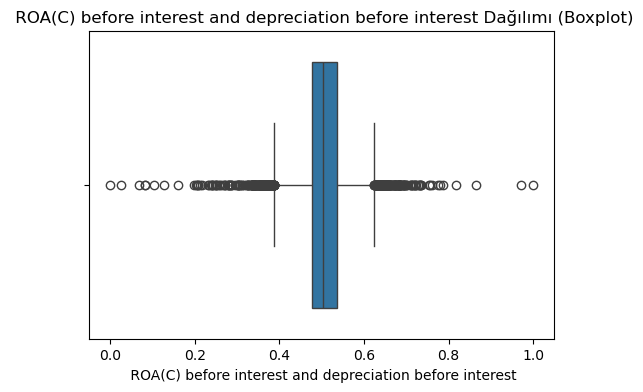

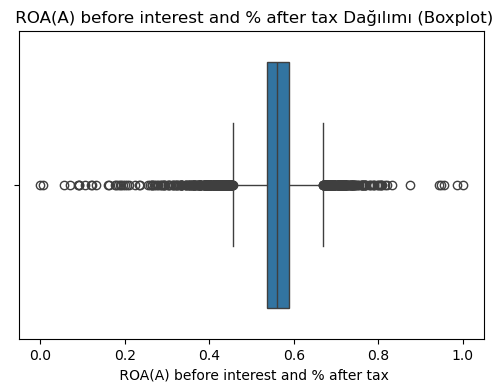

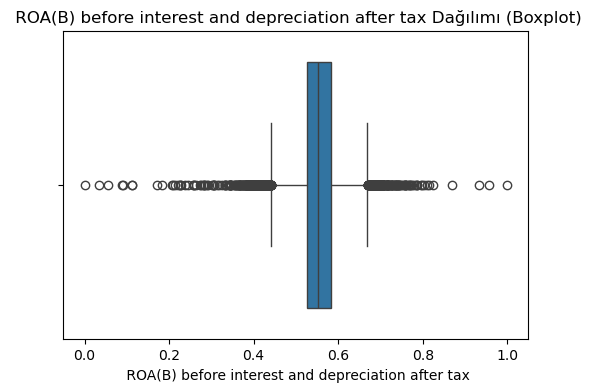

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1) Sayısal sütunları bulun (target dışındaki tüm numerikler)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Bankrupt?')
print("Sayısal sütunlar:", list(numeric_cols))

# 2) Örneğin ilk üç sayısal sütun için kutu grafikleri çizelim
for col in numeric_cols[:3]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Dağılımı (Boxplot)")
    plt.xlabel(col)
    plt.show()


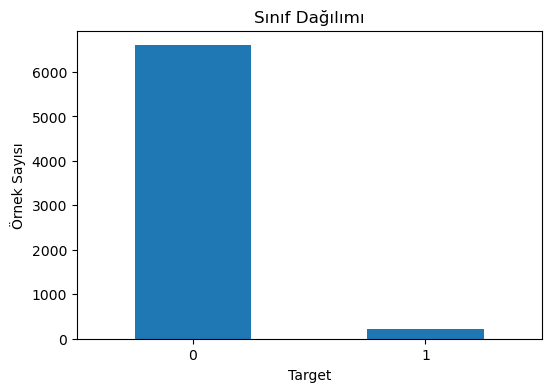

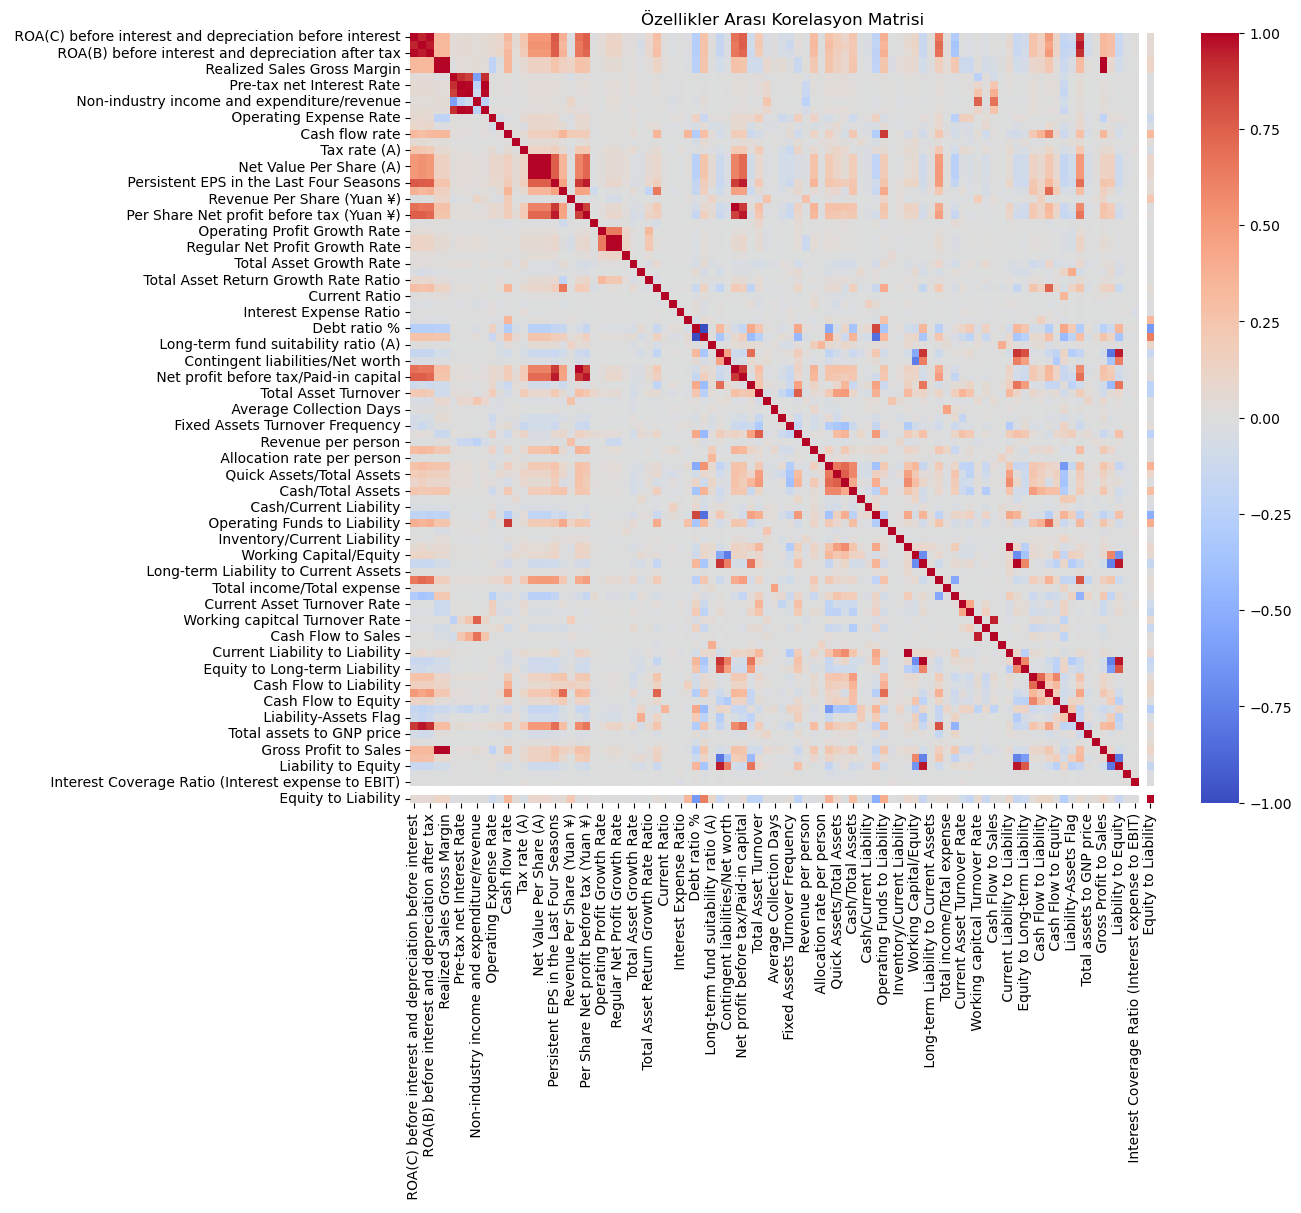

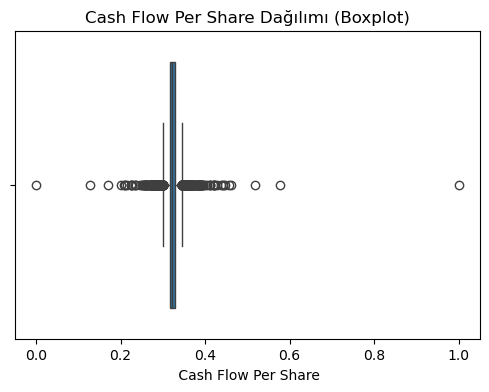

In [9]:
# -----------------------------
# Görselleştirme
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns  # sadece ısı haritası için; istersen matplotlib ile de çizebilirsin

# 1) Sınıf dağılımı
plt.figure(figsize=(6,4))
df['Bankrupt?'].value_counts().sort_index().plot(kind='bar')
plt.title('Sınıf Dağılımı')
plt.xlabel('Target')
plt.ylabel('Örnek Sayısı')
plt.xticks(rotation=0)
plt.show()

# 2) Korelasyon matrisi ve ısı haritası
plt.figure(figsize=(12,10))
corr = df.drop('Bankrupt?', axis=1).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Özellikler Arası Korelasyon Matrisi')
plt.show()

# 3) Örnek bir sayısal değişkenin kutu grafiği (aykırı değerler)
plt.figure(figsize=(6,4))
sns.boxplot(x=df[' Cash Flow Per Share'])
plt.title('Cash Flow Per Share Dağılımı (Boxplot)')
plt.show()


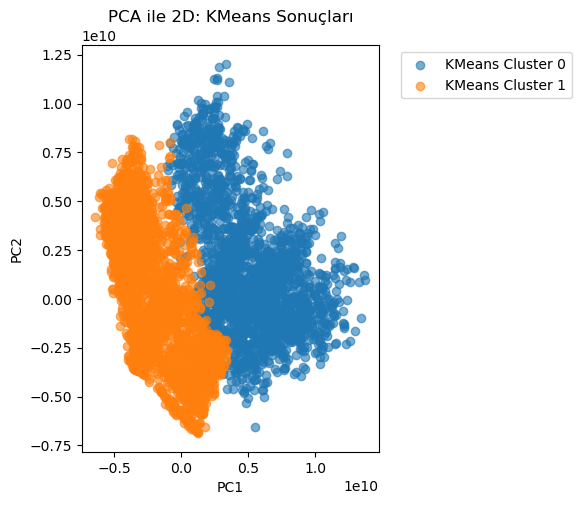

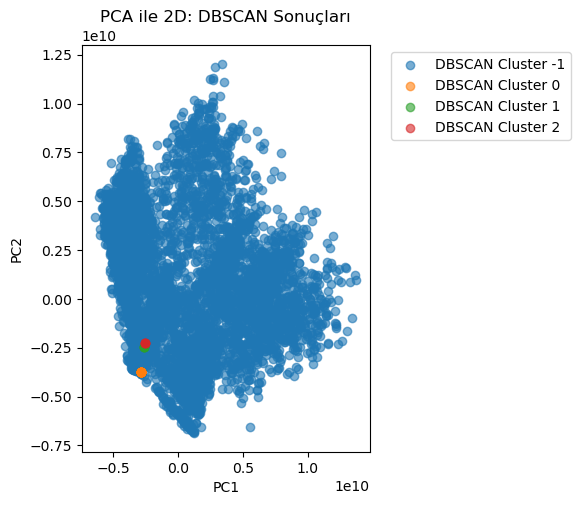

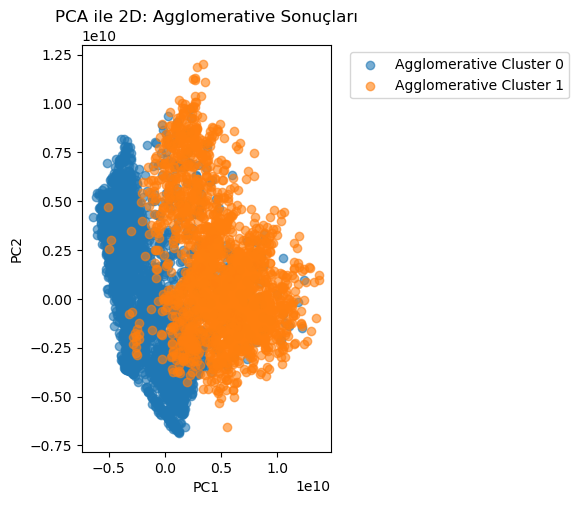

In [10]:
# -------------------------------------------
# Kümeleme Sonuçlarının 2D Görselleştirilmesi
# -------------------------------------------
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

# PCA ile 2 boyuta indirgeme
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(df.drop('Bankrupt?', axis=1))

# Kümeleme algoritmaları ve isimleri
clusterers = [
    (KMeans(n_clusters=df['Bankrupt?'].nunique(), random_state=42), 'KMeans'),
    (DBSCAN(eps=0.5, min_samples=5), 'DBSCAN'),
    (AgglomerativeClustering(n_clusters=df['Bankrupt?'].nunique()), 'Agglomerative')
]

# Her biri için ayrı scatter plot
for model, name in clusterers:
    labels = model.fit_predict(df.drop('Bankrupt?', axis=1))
    plt.figure(figsize=(6,5))
    # -1 DBSCAN için “gürültü” noktasıdır, isterseniz farklı renkle işaretleyebilirsiniz
    unique_labels = np.unique(labels)
    for lbl in unique_labels:
        mask = labels == lbl
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f'{name} Cluster {lbl}',
            alpha=0.6
        )
    plt.title(f'PCA ile 2D: {name} Sonuçları')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

